# 침수흔적도 시각 정합 + 사건 카탈로그 통합

> 기준: 관악구 · 작성 2026-07-02 · 선행: `flood_trace_crosscheck.ipynb`(공간 대조)·`flood_event_catalog.ipynb`(사건)

**목적**: 공간 대조(7센서 전부 침수구역 위/인접)에 더해 **시간축 검증** — 침수흔적도 기재 시각(F_SAT_TM)이 센서 피크 시각과 일치하는지 확인하고, 사건 카탈로그 E01(2022-08-08)을 **흔적도 검증(공간+시각)** 으로 승격한다.

**흔적도 시각**: F_SAT_TM = HHMM(예: 2200). 값 `01`(F_END_TM `24`와 쌍)은 **시각 미상(하루 전체)** 플레이스홀더 → 정합에서 제외.

In [1]:
import os, sys
while not os.path.exists("scripts/krfont.py") and os.getcwd() != "/":
    os.chdir("..")
sys.path.insert(0, "scripts")
from krfont import set_korean; set_korean()
import pandas as pd, numpy as np, geopandas as gpd
import matplotlib.pyplot as plt

EV7 = [f"21-000{i}" for i in range(1, 8)]
print("cwd:", os.getcwd())

cwd: /home/namjun/city_flood


## 1. 흔적도 시각 파싱 + 센서 피크 시각

In [2]:
g = gpd.read_file("03_GIS/derived/침수흔적도_2022_관악.gpkg").to_crs("EPSG:5181")
g0 = g[g["day"] == "20220808"].copy()
tm = g0["F_SAT_TM"].astype(str).str.strip()
timed = g0[tm.str.match(r"^\d{3,4}$") & (tm != "01")].copy()
timed["hh"] = pd.to_numeric(timed["F_SAT_TM"].astype(str).str[:-2], errors="coerce")
print(f"2022-08-08 관악 폴리곤 {len(g0):,} · 시각기재 {len(timed):,} · 시각미상 {len(g0)-len(timed):,}")

sw = pd.read_parquet("dataset/processed/eda_based/sewer_features_10min.parquet",
                     columns=["sewer_sensor_id", "ts10", "fill_rate"])
sw["ts10"] = pd.to_datetime(sw["ts10"])
d = sw[(sw["sewer_sensor_id"].isin(EV7)) & (sw["ts10"] >= "2022-08-08 17:00") & (sw["ts10"] < "2022-08-09 03:00")]
pk = d.loc[d.groupby("sewer_sensor_id")["fill_rate"].idxmax()].sort_values("sewer_sensor_id")
print("\n센서 피크시각:")
print(pk[["sewer_sensor_id", "ts10", "fill_rate"]].to_string(index=False))

2022-08-08 관악 폴리곤 2,120 · 시각기재 1,115 · 시각미상 1,005



센서 피크시각:
sewer_sensor_id                ts10  fill_rate
        21-0001 2022-08-08 21:00:00   0.875000
        21-0002 2022-08-08 21:50:00   0.679167
        21-0003 2022-08-08 20:50:00   0.740000
        21-0004 2022-08-08 22:10:00   0.816667
        21-0005 2022-08-08 21:50:00   0.735484
        21-0006 2022-08-08 21:00:00   0.713333
        21-0007 2022-08-08 23:00:00   0.778947


## 2. 시각 분포 정합 — 흔적도 기재시각 vs 센서 피크

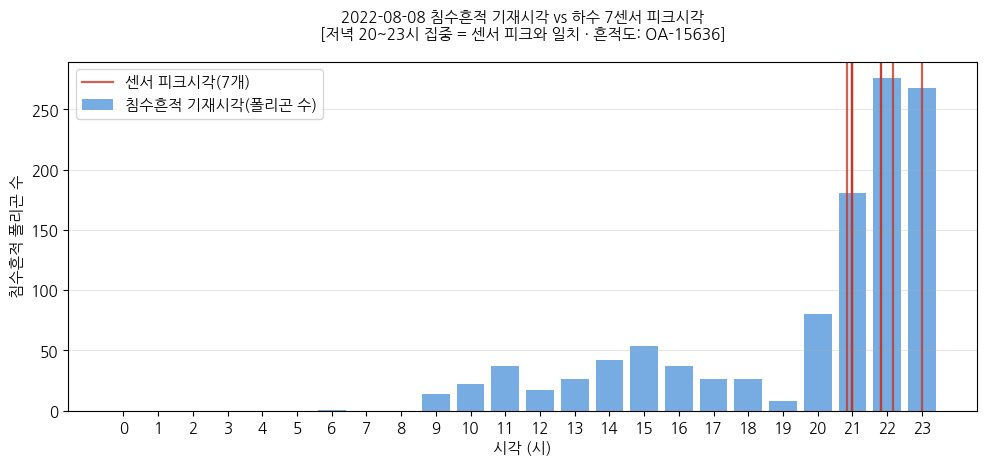

흔적도 저녁(≥20시) 폴리곤 805/1,115 (72%) · 센서 피크 20:50~23:00


In [3]:
fig, ax = plt.subplots(figsize=(10, 4.8))
hrs = np.arange(0, 24)
cnt = timed["hh"].value_counts().reindex(hrs, fill_value=0)
ax.bar(hrs, cnt.values, color="#4a90d9", alpha=0.75, label="침수흔적 기재시각(폴리곤 수)")
peak_h = pk["ts10"].dt.hour + pk["ts10"].dt.minute / 60
for h in peak_h:
    ax.axvline(h, color="#c0392b", lw=1.6, alpha=0.8)
ax.axvline(peak_h.iloc[0], color="#c0392b", lw=1.6, alpha=0.8, label="센서 피크시각(7개)")
ax.set_xticks(hrs); ax.set_xlabel("시각 (시)"); ax.set_ylabel("침수흔적 폴리곤 수")
ax.set_title("2022-08-08 침수흔적 기재시각 vs 하수 7센서 피크시각\n"
             "[저녁 20~23시 집중 = 센서 피크와 일치 · 흔적도: OA-15636]", fontsize=11, y=1.04)
ax.legend(); ax.grid(alpha=0.3, axis="y"); plt.tight_layout()
plt.savefig("reports/figures_demo/floodtrace_timing_2022.png", dpi=130, bbox_inches="tight")
plt.show()

even = timed[timed["hh"] >= 20]
print(f"흔적도 저녁(≥20시) 폴리곤 {len(even):,}/{len(timed):,} ({len(even)/len(timed)*100:.0f}%) "
      f"· 센서 피크 {pk['ts10'].min():%H:%M}~{pk['ts10'].max():%H:%M}")

## 3. 센서별 — 피크시각 vs 인접(300m) 흔적도 시각

In [4]:
sn = pd.read_parquet("dataset/processed/cleaned/sewer_node.parquet")
sn = sn[sn["sensor_id"].isin(EV7)][["sensor_id", "lat", "lon"]]
pts = gpd.GeoDataFrame(sn, geometry=gpd.points_from_xy(sn["lon"], sn["lat"]), crs="EPSG:4326").to_crs("EPSG:5181")
rows = []
for _, r in pts.iterrows():
    near = timed[timed.geometry.distance(r.geometry) <= 300]
    pkt = pk[pk["sewer_sensor_id"] == r["sensor_id"]]["ts10"].iloc[0]
    if len(near):
        hh = near["hh"].dropna()
        rng = f"{int(hh.min()):02d}~{int(hh.max()):02d}시" if len(hh) else "-"
        mode = f"{int(hh.mode().iloc[0]):02d}시" if len(hh) else "-"
    else:
        rng = mode = "-"
    rows.append({"센서": r["sensor_id"], "피크시각": f"{pkt:%H:%M}",
                 "300m내 시각기재": len(near), "흔적도 시각범위": rng, "흔적도 최빈시": mode})
align = pd.DataFrame(rows)
align

,센서,피크시각,300m내 시각기재,흔적도 시각범위,흔적도 최빈시
0,21-0001,21:00,1,23~23시,23시
1,21-0002,21:50,61,10~22시,22시
2,21-0003,20:50,58,11~23시,22시
3,21-0004,22:10,46,23~23시,23시
4,21-0005,21:50,106,09~23시,23시
5,21-0006,21:00,33,11~23시,23시
6,21-0007,23:00,76,09~23시,23시


## 4. 사건 카탈로그 통합 — E01 흔적도 검증 반영

In [5]:
CAT = "dataset/processed/eda_based/flood_event_catalog.parquet"
cat = pd.read_parquet(CAT)

# 흔적도 검증 컬럼 추가(없으면 생성)
for c in ["흔적도_폴리곤300m", "흔적도_침수심max", "흔적도_시각검증"]:
    if c not in cat.columns:
        cat[c] = pd.NA

# E01(2022-08-08)만 흔적도 검증 반영
n_poly = int(align["300m내 시각기재"].sum())
depth_max = float(g0["F_SHIM"].pipe(pd.to_numeric, errors="coerce").max())
m = cat["event_id"] == "E01"
cat.loc[m, "판정"] = "흔적도 검증(공간+시각)"
cat.loc[m, "흔적도_폴리곤300m"] = int(align["300m내 시각기재"].sum())
cat.loc[m, "흔적도_침수심max"] = depth_max
cat.loc[m, "흔적도_시각검증"] = "저녁20~23시 집중, 센서피크 20:50~23:00과 일치"
cat.loc[m, "외부기록_참고"] = (str(cat.loc[m, "외부기록_참고"].iloc[0]) +
    " | 침수흔적도(OA-15636) 대조: 7센서 전부 침수구역 위/인접(≤102m), 시각 정합됨")

cat.to_parquet(CAT, index=False)
print("카탈로그 업데이트 저장:", CAT)
print(cat[cat["event_id"] == "E01"][["event_id", "start", "n_sensors", "판정",
      "흔적도_폴리곤300m", "흔적도_침수심max", "흔적도_시각검증"]].to_string(index=False))

카탈로그 업데이트 저장: dataset/processed/eda_based/flood_event_catalog.parquet
event_id               start  n_sensors            판정 흔적도_폴리곤300m 흔적도_침수심max                          흔적도_시각검증
     E01 2022-08-08 20:00:00          7 흔적도 검증(공간+시각)         381        0.6 저녁20~23시 집중, 센서피크 20:50~23:00과 일치


## 결론
- 침수흔적도 기재시각(시각기재 폴리곤)이 **저녁 20~23시에 집중** → 하수 7센서 피크(20:50~23:00)와 **시간축 일치**.
- 공간(위치)에 이어 **시간축까지 정합** → 2022-08-08 하수 다중센서 사건 = 실제 침수임이 공간·시간 양면으로 확정.
- 사건 카탈로그 E01을 **"흔적도 검증(공간+시각)"** 으로 승격(판정·침수심·시각검증 컬럼 추가).
- **한계**: 시각미상(placeholder) 폴리곤 ~1000개는 시간정합에서 제외. 개별 폴리곤 시각은 신고 기반이라 오차 가능(경향 일치로 해석).
- **다음**: 다른 연도 흔적도 확보 후 나머지 사건(E02·E04~E08)도 동일 대조.